# OPTIMAL HYPERPLANE

Weights: [0.8 0.4]
Bias: -1.8000000000000003

Optimal hyperplane:
0.80 x1 + 0.40 x2 + -1.80 = 0


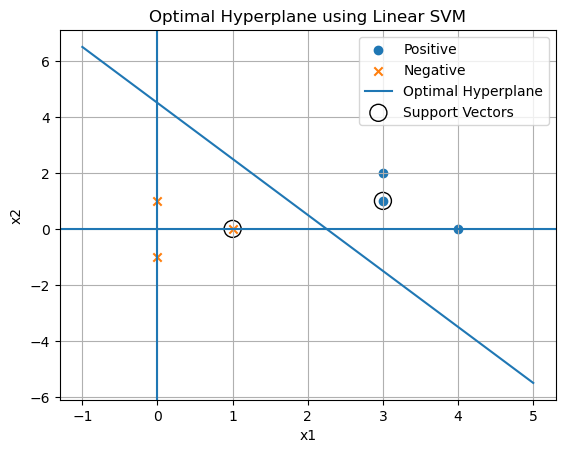

In [1]:
 import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Positive class
positive = np.array([
    [3, 1],
    [3, 2],
    [4, 0]
])

# Negative class
negative = np.array([
    [1, 0],
    [0, 1],
    [0, -1]
])

# Combine data
X = np.vstack((positive, negative))
y = np.array([1, 1, 1, -1, -1, -1])

# Linear SVM
model = SVC(kernel='linear', C=1000000)
model.fit(X, y)

# Get weights and bias
w = model.coef_[0]
b = model.intercept_[0]

print("Weights:", w)
print("Bias:", b)

print("\nOptimal hyperplane:")
print(f"{w[0]:.2f} x1 + {w[1]:.2f} x2 + {b:.2f} = 0")

# Plot points
plt.scatter(
    positive[:, 0],
    positive[:, 1],
    marker='o',
    label='Positive'
)

plt.scatter(
    negative[:, 0],
    negative[:, 1],
    marker='x',
    label='Negative'
)

# Hyperplane
x1 = np.linspace(-1, 5, 100)
x2 = -(w[0] * x1 + b) / w[1]

plt.plot(x1, x2, label='Optimal Hyperplane')

# Support vectors
sv = model.support_vectors_

plt.scatter(
    sv[:, 0],
    sv[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    label='Support Vectors'
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.legend()
plt.title("Optimal Hyperplane using Linear SVM")
plt.show()

# MLP

In [3]:
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7]
])

y = np.array([0, 0, 0, 1, 1, 1])


mlp = MLPClassifier(
    max_iter=2000,
    random_state=42
)


model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp)
])


param_grid = {

   
    'mlp__hidden_layer_sizes': [
        (5,),
        (10,),
        (20,),
        (10, 5),
        (20, 10)
    ],

  
    'mlp__activation': [
        'relu',
        'tanh',
        'logistic'
    ],

   
    'mlp__learning_rate_init': [
        0.001,
        0.01,
        0.1
    ],

  
    'mlp__alpha': [
        0.0001,
        0.001,
        0.01
    ],

   
    'mlp__solver': [
        'adam'
    ]
}




grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("BEST PARAMETERS")
print("----------------")
print(grid_search.best_params_)


print("\nBEST CV ACCURACY")
print("----------------")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_


y_pred = best_model.predict(X)


print("\nPREDICTIONS")
print("-----------")

for actual, predicted in zip(y, y_pred):
    print("Actual:", actual,
          "Predicted:", predicted)

accuracy = accuracy_score(y, y_pred)

print("\nFINAL ACCURACY")
print("--------------")
print(accuracy)

print("\nCLASSIFICATION REPORT")
print("---------------------")
print(classification_report(y, y_pred))

BEST PARAMETERS
----------------
{'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (5,), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}

BEST CV ACCURACY
----------------
0.8333333333333334

PREDICTIONS
-----------
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1

FINAL ACCURACY
--------------
1.0

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [4]:
  import numpy as np

def abs(x):
    return x if x > 0 else -x

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def checkError(predicted_output):
    expected_output = [[0], [1], [1], [0]]
    for i, j in zip(expected_output, predicted_output):
        if abs(i[0] - j[0]) > 0.001:
            return True
    return False


inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

expected_output = np.array([
    [0],
    [1],
    [1],
    [0]
])

epoch = 0
lr = 0.1

inputLayerNeurons = int(input("Enter no of input layer: "))
hiddenLayerNeurons = int(input("Enter no of hidden layer: "))
outputLayerNeurons = int(input("Enter no of output layer: "))

hidden_weights = []

for i in range(1, inputLayerNeurons + 1):
    temp = []
    for j in range(
        inputLayerNeurons + 1,
        inputLayerNeurons + hiddenLayerNeurons + 1
    ):
        temp.append(float(input("w" + str(i) + str(j) + ": ")))
    hidden_weights.append(temp)

output_weights = []

for i in range(
    inputLayerNeurons + 1,
    inputLayerNeurons + hiddenLayerNeurons + 1
):
    temp = []
    for j in range(
        inputLayerNeurons + hiddenLayerNeurons + 1,
        inputLayerNeurons + hiddenLayerNeurons + outputLayerNeurons + 1
    ):
        temp.append(float(input("w" + str(i) + str(j) + ": ")))
    output_weights.append(temp)

hidden_bias = []
output_bias = []

for i in range(
    inputLayerNeurons + 1,
    inputLayerNeurons + hiddenLayerNeurons + outputLayerNeurons + 1
):
    if i > inputLayerNeurons + hiddenLayerNeurons:
        output_bias.append(float(input("o" + str(i) + ": ")))
    else:
        hidden_bias.append(float(input("o" + str(i) + ": ")))

hidden_weights = np.asarray(hidden_weights)
hidden_bias = np.asarray([hidden_bias])
output_weights = np.asarray(output_weights)
output_bias = np.asarray([output_bias])

print("Initial hidden weights:", *hidden_weights)
print("Initial hidden biases:", *hidden_bias)
print("Initial output weights:", *output_weights)
print("Initial output biases:", *output_bias)

predicted_output = np.zeros((4, 1))

while checkError(predicted_output):

    epoch += 1

    hidden_layer_activation = np.dot(inputs, hidden_weights)
    hidden_layer_activation += hidden_bias

    hidden_layer_output = sigmoid(hidden_layer_activation)

    output_layer_activation = np.dot(
        hidden_layer_output,
        output_weights
    )

    output_layer_activation += output_bias

    predicted_output = sigmoid(output_layer_activation)

    error = expected_output - predicted_output

    d_predicted_output = (
        error * sigmoid_derivative(predicted_output)
    )

    error_hidden_layer = d_predicted_output.dot(
        output_weights.T
    )

    d_hidden_layer = (
        error_hidden_layer *
        sigmoid_derivative(hidden_layer_output)
    )

    output_weights += (
        hidden_layer_output.T.dot(d_predicted_output) * lr
    )

    output_bias += (
        np.sum(d_predicted_output, axis=0, keepdims=True) * lr
    )

    hidden_weights += (
        inputs.T.dot(d_hidden_layer) * lr
    )

    hidden_bias += (
        np.sum(d_hidden_layer, axis=0, keepdims=True) * lr
    )


print("\nInitial training completed")
print("Epochs:", epoch)

print("\nFine-Tuning Started")

fine_tune_lr = 0.01
fine_tune_epochs = 1000

for i in range(fine_tune_epochs):

    hidden_layer_activation = np.dot(inputs, hidden_weights)
    hidden_layer_activation += hidden_bias

    hidden_layer_output = sigmoid(hidden_layer_activation)

    output_layer_activation = np.dot(
        hidden_layer_output,
        output_weights
    )

    output_layer_activation += output_bias

    predicted_output = sigmoid(output_layer_activation)

    error = expected_output - predicted_output

    d_predicted_output = (
        error * sigmoid_derivative(predicted_output)
    )

    error_hidden_layer = d_predicted_output.dot(
        output_weights.T
    )

    d_hidden_layer = (
        error_hidden_layer *
        sigmoid_derivative(hidden_layer_output)
    )

    output_weights += (
        hidden_layer_output.T.dot(d_predicted_output)
        * fine_tune_lr
    )

    output_bias += (
        np.sum(d_predicted_output, axis=0, keepdims=True)
        * fine_tune_lr
    )

    hidden_weights += (
        inputs.T.dot(d_hidden_layer)
        * fine_tune_lr
    )

    hidden_bias += (
        np.sum(d_hidden_layer, axis=0, keepdims=True)
        * fine_tune_lr
    )


print("Fine-Tuning Completed")

print("\nFinal hidden weights:")
print(*hidden_weights)

print("\nFinal hidden bias:")
print(*hidden_bias)

print("\nFinal output weights:")
print(*output_weights)

print("\nFinal output bias:")
print(*output_bias)

print("\nOutput from neural network:")
print(*predicted_output)

print("\nTotal fine-tuning epochs:")
print(fine_tune_epochs)

Enter no of input layer:  2
Enter no of hidden layer:  3
Enter no of output layer:  1
w13:  2
w14:  .4
w15:  .2
w23:  -.2
w24:  .3
w25:  .1
w36:  2
w46:  5
w56:  1
o3:  .1
o4:  .2
o5:  .3
o6:  .4


Initial hidden weights: [2.  0.4 0.2] [-0.2  0.3  0.1]
Initial hidden biases: [0.1 0.2 0.3]
Initial output weights: [2.] [5.] [1.]
Initial output biases: [0.4]

Initial training completed
Epochs: 12865627

Fine-Tuning Started
Fine-Tuning Completed

Final hidden weights:
[ 7.32845972 -7.56039649 -0.27836519] [-7.50165428  7.42173027  0.34887997]

Final hidden bias:
[-3.95327405 -3.9861282   1.1630266 ]

Final output weights:
[14.84934029] [15.08283615] [-2.50889098]

Final output bias:
[-5.54990137]

Output from neural network:
[0.001] [0.99909516] [0.99911815] [0.00089565]

Total fine-tuning epochs:
1000


In [5]:
 import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("Iris.csv")

X = df.iloc[:, :-1].values.astype("float32")
y = LabelEncoder().fit_transform(df.iloc[:, -1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Initial Training")

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Accuracy before fine-tuning:", accuracy)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nFine-Tuning")

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=8,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Accuracy after fine-tuning:", accuracy)

Initial Training
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1750 - loss: 3.2430  
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1750 - loss: 2.9761 
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750 - loss: 2.7272 
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1750 - loss: 2.4921 
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750 - loss: 2.2901 
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750 - loss: 2.0983 
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1750 - loss: 1.9374 
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750 - loss: 1.7935 
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750 - loss: 1.6652 
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1750 - loss: 1.5651 
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1750 - loss: 1.4799 
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1750

In [ ]:
import math
a0=5
a1=2
a2=2
e1=2/math.sqrt(a1**2+a2**2)
b0=3
b1=20
b2=20
e2=2/math.sqrt(b1**2+b2**2)
print("Classifier 1: ")
print(a0,"+",a1,"x1+",a2,"x2=0")
print("Distance error: ",e1)
print("Classifier 2: ")
print(b0,"+",b1,"x1+",b2,"x2=0")
print("Distance error: ",e2)
if e1>e2:
    print("\nClassifier 1 is the good classifier")
elif e2>e1:
    print("\nClassifier 2 is the good classifier")
else:
    print("Both are equally good")